In [11]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, make_scorer


## Definisanje skupova podataka po algoritmu. Razliciti algoritmi imaju razlicite zahteve

In [21]:
data_topK_genes_smoted = [f'data_top{k}_genes_smote' for k in [20, 30, 40, 50, 100, 200]]
data_pcaK              = [f'data_pca{k}' for k in [70, 80]]
data_pcaK_smoted       = [f'data_pca{k}_smoted' for k in [70, 80]]
data_raw               = ['data_raw']
data_scaled            = ['data_scaled']
data_smoted            = ['data_smote']

logistic_regression_data = data_pcaK + data_pcaK_smoted + data_topK_genes_smoted
naiveBayes_data          = data_raw + data_scaled + data_smoted + data_topK_genes_smoted + data_pcaK + data_pcaK_smoted
XGboost_data             = data_topK_genes_smoted + data_pcaK + data_pcaK_smoted
RandomForest_data        = data_topK_genes_smoted + data_pcaK + data_pcaK_smoted
SVM_data                 = data_pcaK + data_pcaK_smoted + data_topK_genes_smoted
KNN_data                 = [f'data_top{k}_genes_smote' for k in [20, 30, 40, 50]]

print('Skupovi po algoritmu:')
print(f'  Logisticka regresija: {len(logistic_regression_data)} fajlova')
print(f'  Naivni Bayes:         {len(naiveBayes_data)} fajlova')
print(f'  XGBoost:              {len(XGboost_data)} fajlova')
print(f'  Random Forest:        {len(RandomForest_data)} fajlova')
print(f'  Linear SVM:           {len(SVM_data)} fajlova')
print(f'  k-NN:                 {len(KNN_data)} fajlova')


Skupovi po algoritmu:
  Logisticka regresija: 10 fajlova
  Naivni Bayes:         13 fajlova
  XGBoost:              10 fajlova
  Random Forest:        10 fajlova
  Linear SVM:           10 fajlova
  k-NN:                 4 fajlova


##  Pomocne funkcije da bismo izbegli ponavljanje koda

In [24]:
def run_classifier(model_factory, base_names, param_grid, label_map=None):
    keys = list(param_grid.keys())
    values = list(param_grid.values())
    pos_label = 1 if label_map else 'Colon'

    # Scorer-i koji eksplicitno govore koja je pozitivna klasa
    # (kljucno za stringovne labele 'Colon'/'Other' i sprecava NaN F1)
    scorers = {
        'f1':       make_scorer(f1_score, pos_label=pos_label, zero_division=0),
        'accuracy': 'accuracy'
    }
    all_rows = []

    for base_name in base_names:
        df_tr = pd.read_csv(f'data/{base_name}_train.csv')
        df_te = pd.read_csv(f'data/{base_name}_test.csv')
        X_tr = df_tr.drop('target', axis=1); y_tr = df_tr['target']
        X_te = df_te.drop('target', axis=1); y_te = df_te['target']
        if label_map:
            y_tr = y_tr.map(label_map)
            y_te = y_te.map(label_map)

        for combo in itertools.product(*values):
            params = dict(zip(keys, combo))
            model = model_factory(**params)
            model.fit(X_tr, y_tr)

            cv_res = cross_validate(
                model, X_tr, y_tr, cv=5,
                scoring=scorers,
                n_jobs=-1
            )
            y_pred = model.predict(X_te)

            row = {
                'file': base_name,
                **params,
                'mean_cv_f1': np.nanmean(cv_res['test_f1']) if not np.all(np.isnan(cv_res['test_f1'])) else 0.0,
                'mean_cv_accuracy': cv_res['test_accuracy'].mean(),
                'test_f1':       f1_score(y_te, y_pred, pos_label=pos_label, zero_division=0),
                'test_accuracy': accuracy_score(y_te, y_pred)
            }
            all_rows.append(row)

    return pd.DataFrame(all_rows)


def plot_param_curves(results_df, x_param, group_col=None, log_x=False, title_prefix=''):
    metrics = [('test_f1', 'F1 Score'), ('test_accuracy', 'Accuracy')]

    if group_col is None:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        for ax, (metric, title) in zip(axes, metrics):
            sns.lineplot(data=results_df, x=x_param, y=metric, hue='file', marker='o', ax=ax)
            if log_x: ax.set_xscale('log')
            ax.set_title(f'{title_prefix} - {title} vs {x_param}')
            ax.set_xlabel(x_param + (' (log skala)' if log_x else ''))
            ax.set_ylabel(f'Test {title}')
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
            ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, title='Dataset')
        plt.tight_layout()
        plt.show()
        return

    groups = sorted(results_df[group_col].unique())
    fig, axes = plt.subplots(len(groups), 2, figsize=(16, 5 * len(groups)))
    if len(groups) == 1:
        axes = axes.reshape(1, -1)
    for row, g in enumerate(groups):
        sub = results_df[results_df[group_col] == g]
        for col, (metric, title) in enumerate(metrics):
            ax = axes[row, col]
            sns.lineplot(data=sub, x=x_param, y=metric, hue='file', marker='o', ax=ax)
            if log_x: ax.set_xscale('log')
            ax.set_title(f'{title_prefix} - {title} vs {x_param} ({group_col}={g})')
            ax.set_xlabel(x_param + (' (log skala)' if log_x else ''))
            ax.set_ylabel(f'Test {title}')
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
            if col == 0:
                ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, title='Dataset')
            else:
                ax.get_legend().remove() if ax.get_legend() else None
    plt.tight_layout()
    plt.show()


def plot_best_per_file(results_df, title='Najbolji modeli po skupu'):
    best = results_df.loc[results_df.groupby('file')['test_f1'].idxmax()]
    best = best.sort_values('test_f1', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(best))
    width = 0.35
    bars1 = ax.bar(x - width/2, best['test_f1'],       width, label='F1 Score', color='#3498db')
    bars2 = ax.bar(x + width/2, best['test_accuracy'], width, label='Accuracy', color='#e74c3c')
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(best['file'], rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f'\n=== {title} ===')
    print(best.to_string(index=False))
    print(f'\nF1 vs Accuracy (gap -> nebalansiranost):')
    best_show = best.copy()
    best_show['gap'] = (best_show['test_accuracy'] - best_show['test_f1']).round(4)
    print(best_show[['file', 'test_f1', 'test_accuracy', 'gap']].to_string(index=False))
    return best


## Algoritam 1 - Logisticka regresija

In [25]:
param_grid_lr = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear', 'saga']
}

def lr_factory(**params):
    return LogisticRegression(max_iter=1000, **params)

all_lr = run_classifier(lr_factory, logistic_regression_data, param_grid_lr)
all_lr.to_csv('logistic_regression_all_results.csv', index=False)
print(f'Sacuvano: logistic_regression_all_results.csv ({len(all_lr)} kombinacija)')

Sacuvano: logistic_regression_all_results.csv (160 kombinacija)


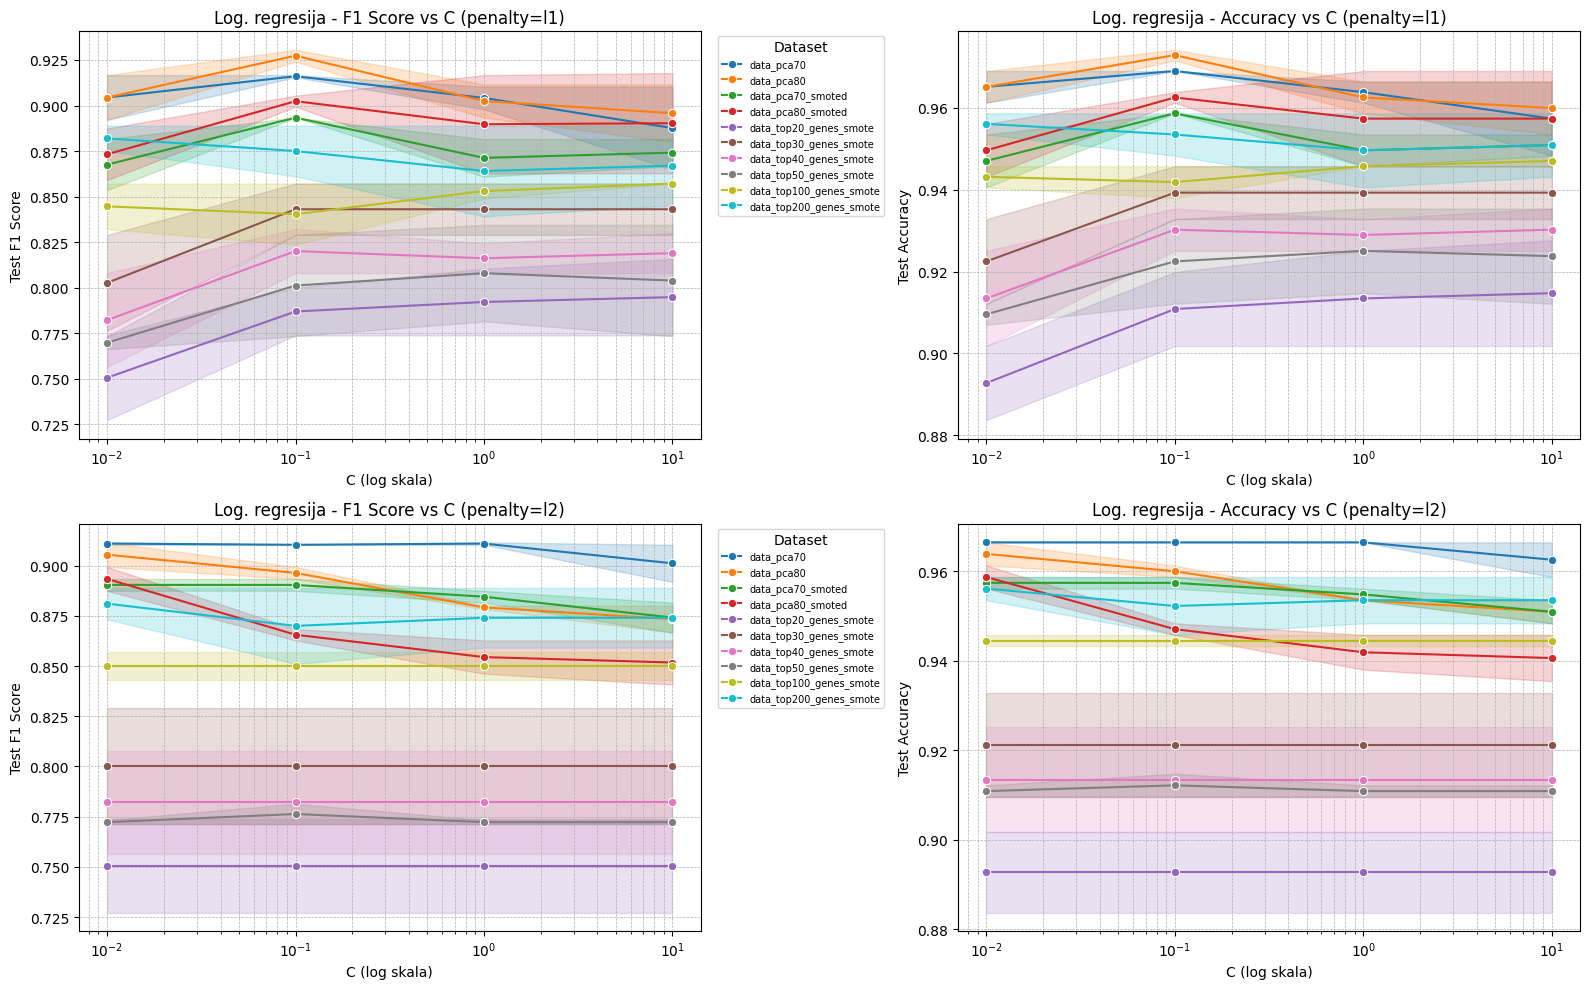

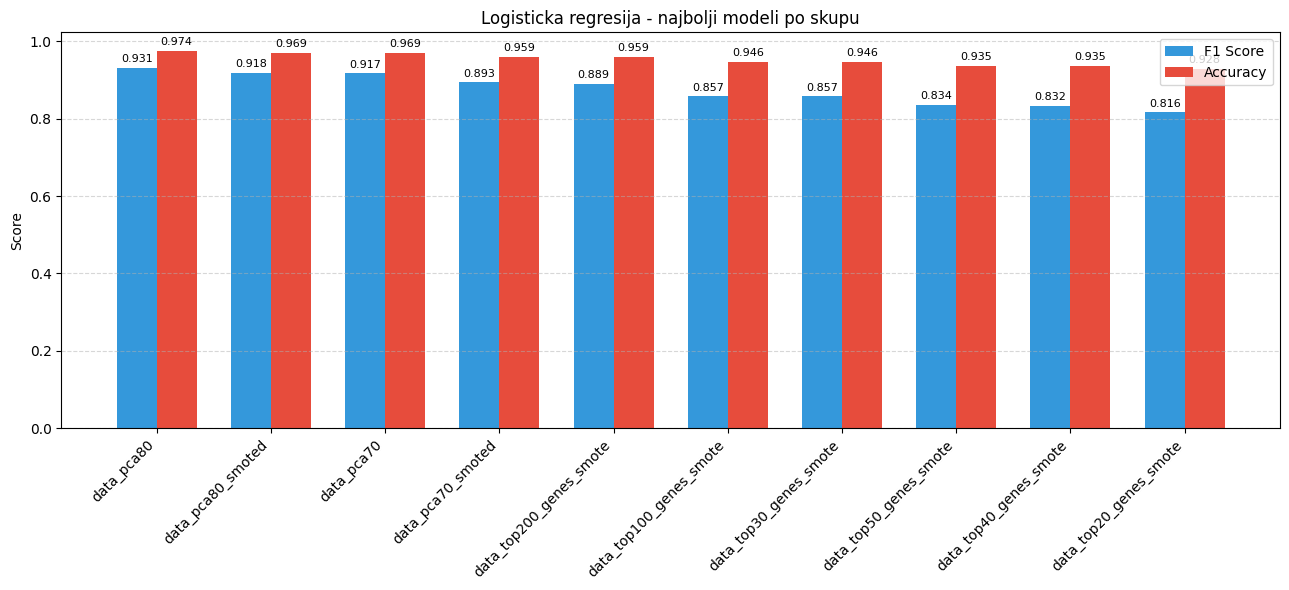


=== Logisticka regresija - najbolji modeli po skupu ===
                   file     C penalty    solver  mean_cv_f1  mean_cv_accuracy  test_f1  test_accuracy
             data_pca80  0.10      l1 liblinear    0.888056          0.957673 0.930556       0.974160
      data_pca80_smoted 10.00      l1 liblinear    0.959917          0.959742 0.917808       0.968992
             data_pca70  0.01      l1 liblinear    0.890450          0.958554 0.916667       0.968992
      data_pca70_smoted  0.01      l2      saga    0.962515          0.961329 0.893333       0.958656
data_top200_genes_smote  0.01      l1      saga    0.957154          0.958170 0.888889       0.958656
data_top100_genes_smote  0.01      l1      saga    0.937865          0.941219 0.857143       0.945736
 data_top30_genes_smote  0.10      l1 liblinear    0.942451          0.943863 0.857143       0.945736
 data_top50_genes_smote  1.00      l1 liblinear    0.892225          0.899385 0.834437       0.935401
 data_top40_genes_smote  

In [26]:
plot_param_curves(all_lr, x_param='C', group_col='penalty', log_x=True, title_prefix='Log. regresija')

best_lr = plot_best_per_file(all_lr, title='Logisticka regresija - najbolji modeli po skupu')

## Algoritam 2 - Naivni Bajesov klasifikator 

In [7]:
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

def nb_factory(**params):
    return GaussianNB(**params)

all_nb = run_classifier(nb_factory, naiveBayes_data, param_grid_nb)
all_nb.to_csv('naive_bayes_all_results.csv', index=False)
print(f'Sacuvano: naive_bayes_all_results.csv ({len(all_nb)} kombinacija)')

Sacuvano: naive_bayes_all_results.csv (78 kombinacija)


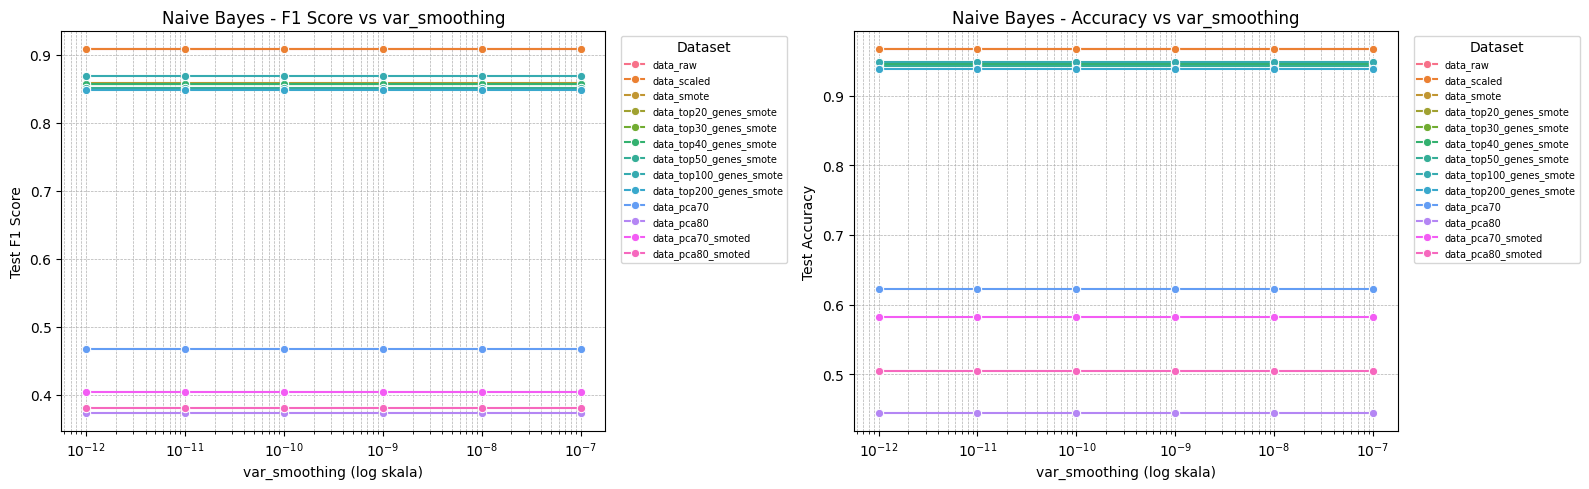

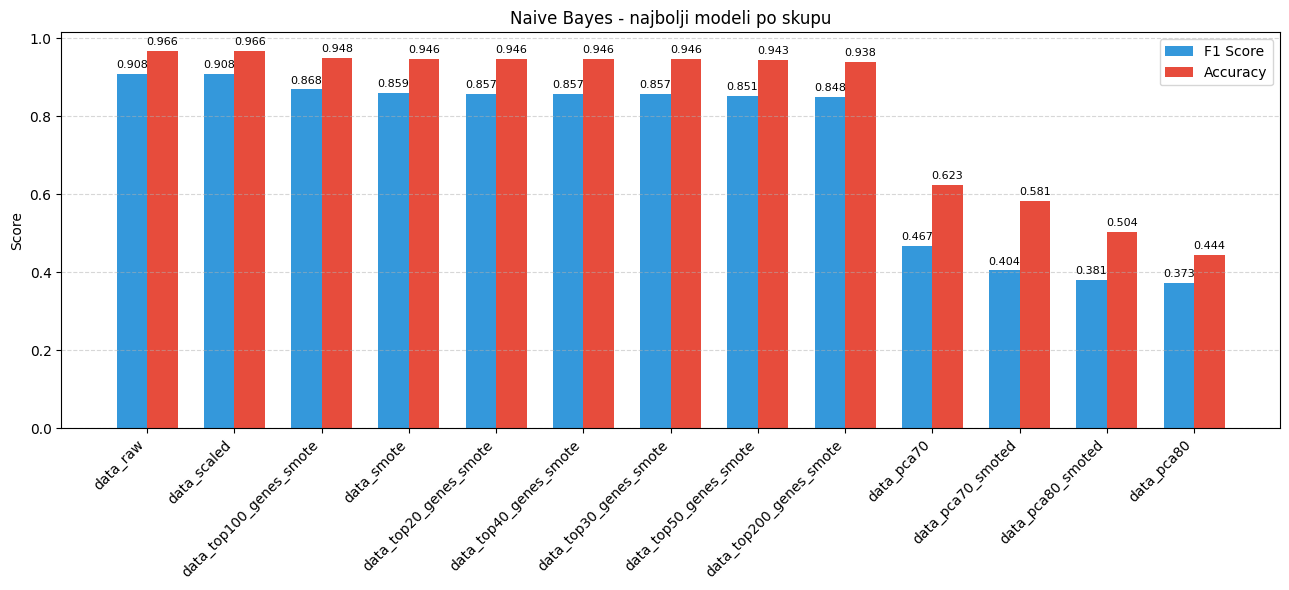


=== Naive Bayes - najbolji modeli po skupu ===
                   file  var_smoothing  mean_cv_f1  mean_cv_accuracy  test_f1  test_accuracy
               data_raw   1.000000e-12    0.904164          0.965469 0.907801       0.966408
            data_scaled   1.000000e-12    0.904164          0.965469 0.907801       0.966408
data_top100_genes_smote   1.000000e-12    0.792763          0.824121 0.868421       0.948320
             data_smote   1.000000e-12    0.957963          0.960295 0.859060       0.945736
 data_top20_genes_smote   1.000000e-12    0.744509          0.793915 0.857143       0.945736
 data_top40_genes_smote   1.000000e-12    0.787980          0.819891 0.857143       0.945736
 data_top30_genes_smote   1.000000e-12    0.825613          0.847424 0.857143       0.945736
 data_top50_genes_smote   1.000000e-12    0.738278          0.788636 0.851351       0.943152
data_top200_genes_smote   1.000000e-12    0.808471          0.832079 0.848101       0.937984
             data_pca7

In [8]:
plot_param_curves(all_nb, x_param='var_smoothing', log_x=True, title_prefix='Naive Bayes')
best_nb = plot_best_per_file(all_nb, title='Naive Bayes - najbolji modeli po skupu')

## Algoritam 3 - XGBoost (gradijentno pojačanje)

In [9]:
param_grid_xgb = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

def xgb_factory(**params):
    return XGBClassifier(
        **params,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        verbosity=0
    )

all_xgb = run_classifier(
    xgb_factory, XGboost_data, param_grid_xgb,
    label_map={'Other': 0, 'Colon': 1}
)
all_xgb.to_csv('xgboost_all_results.csv', index=False)
print(f'Sacuvano: xgboost_all_results.csv ({len(all_xgb)} kombinacija)')

Sacuvano: xgboost_all_results.csv (270 kombinacija)


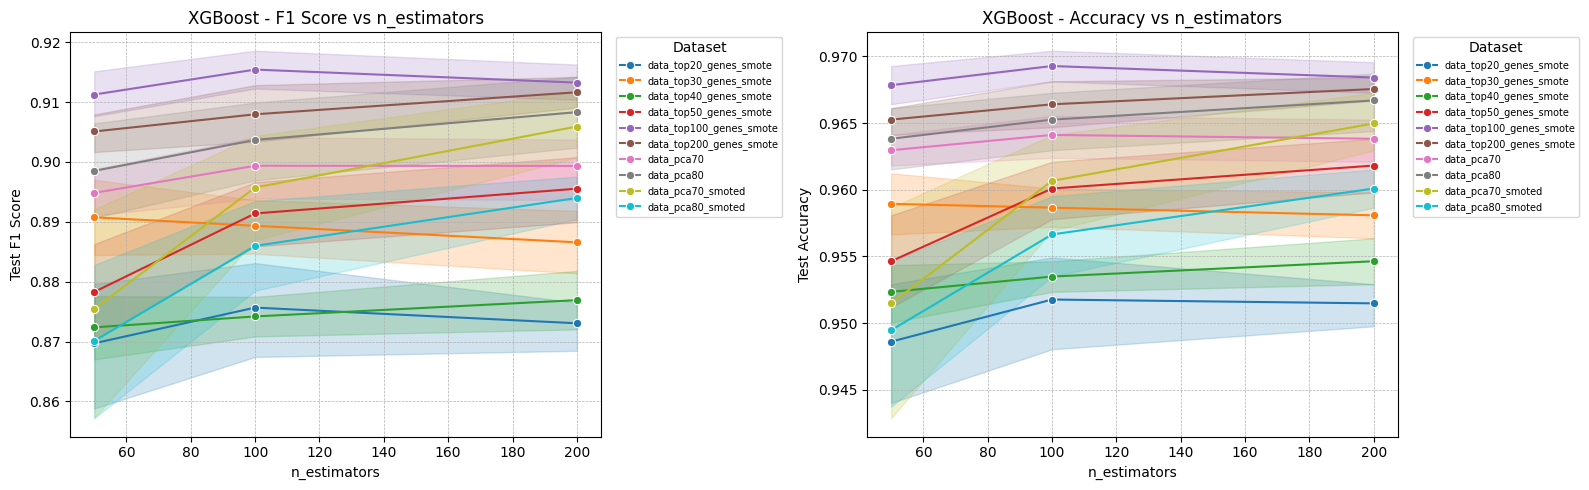

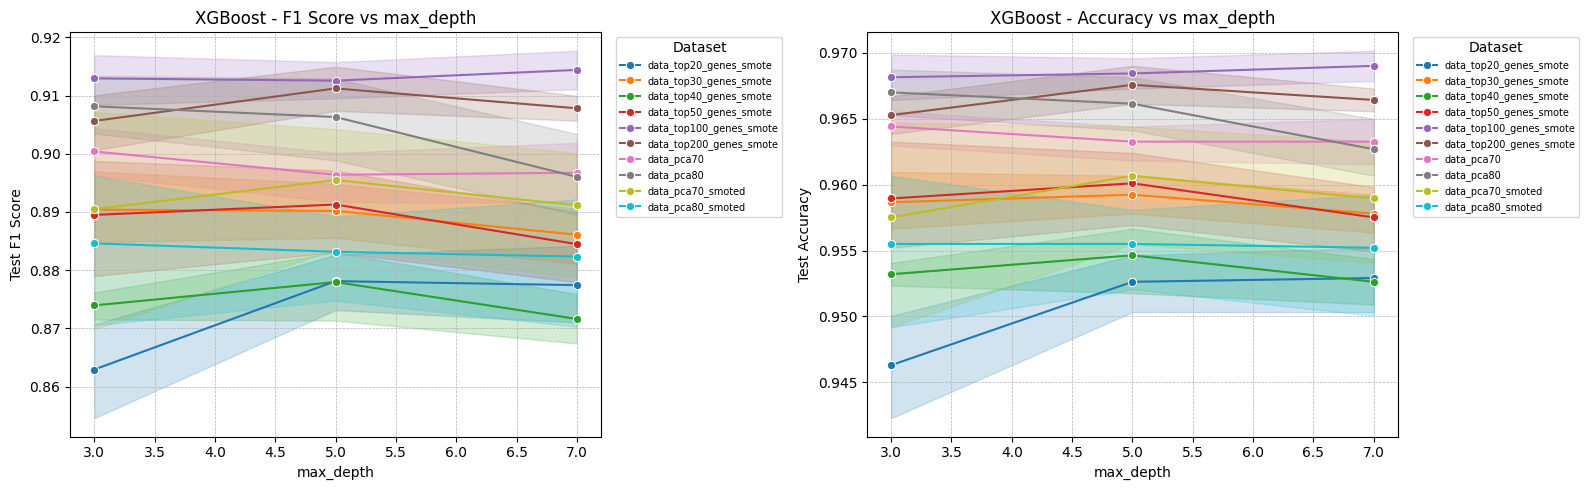

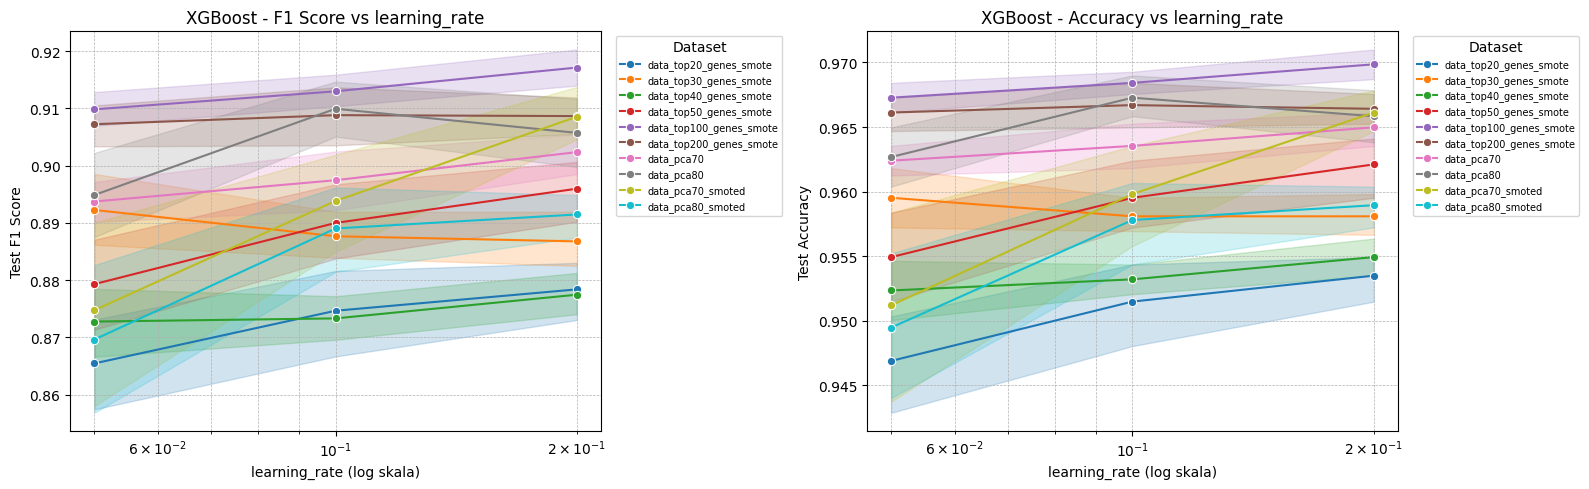

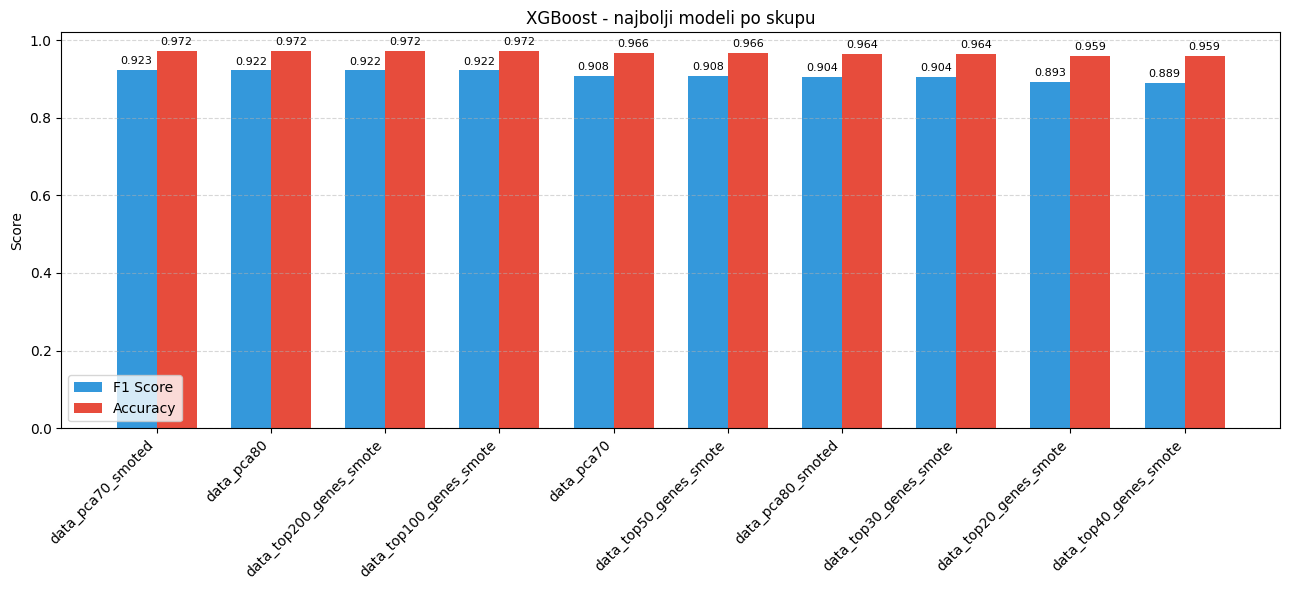


=== XGBoost - najbolji modeli po skupu ===
                   file  n_estimators  max_depth  learning_rate  mean_cv_f1  mean_cv_accuracy  test_f1  test_accuracy
      data_pca70_smoted           200          3           0.20    0.967740          0.969291 0.923077       0.971576
             data_pca80           200          3           0.10    0.894913          0.962879 0.921986       0.971576
data_top200_genes_smote           100          5           0.10    0.984464          0.984648 0.921986       0.971576
data_top100_genes_smote            50          3           0.20    0.980107          0.980408 0.921986       0.971576
             data_pca70           100          3           0.20    0.900885          0.964599 0.907801       0.966408
 data_top50_genes_smote           200          3           0.10    0.978105          0.978289 0.907801       0.966408
      data_pca80_smoted           100          3           0.10    0.958243          0.961889 0.904110       0.963824
 data_top30_

In [10]:
plot_param_curves(all_xgb, x_param='n_estimators',  title_prefix='XGBoost')
plot_param_curves(all_xgb, x_param='max_depth',     title_prefix='XGBoost')
plot_param_curves(all_xgb, x_param='learning_rate', log_x=True, title_prefix='XGBoost')

best_xgb = plot_best_per_file(all_xgb, title='XGBoost - najbolji modeli po skupu')

## Algoritam 4 - Random Forest

In [11]:
param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

def rf_factory(**params):
    return RandomForestClassifier(**params, random_state=42, n_jobs=-1)

all_rf = run_classifier(rf_factory, RandomForest_data, param_grid_rf)
all_rf.to_csv('random_forest_all_results.csv', index=False)
print(f'Sacuvano: random_forest_all_results.csv ({len(all_rf)} kombinacija)')

Sacuvano: random_forest_all_results.csv (360 kombinacija)


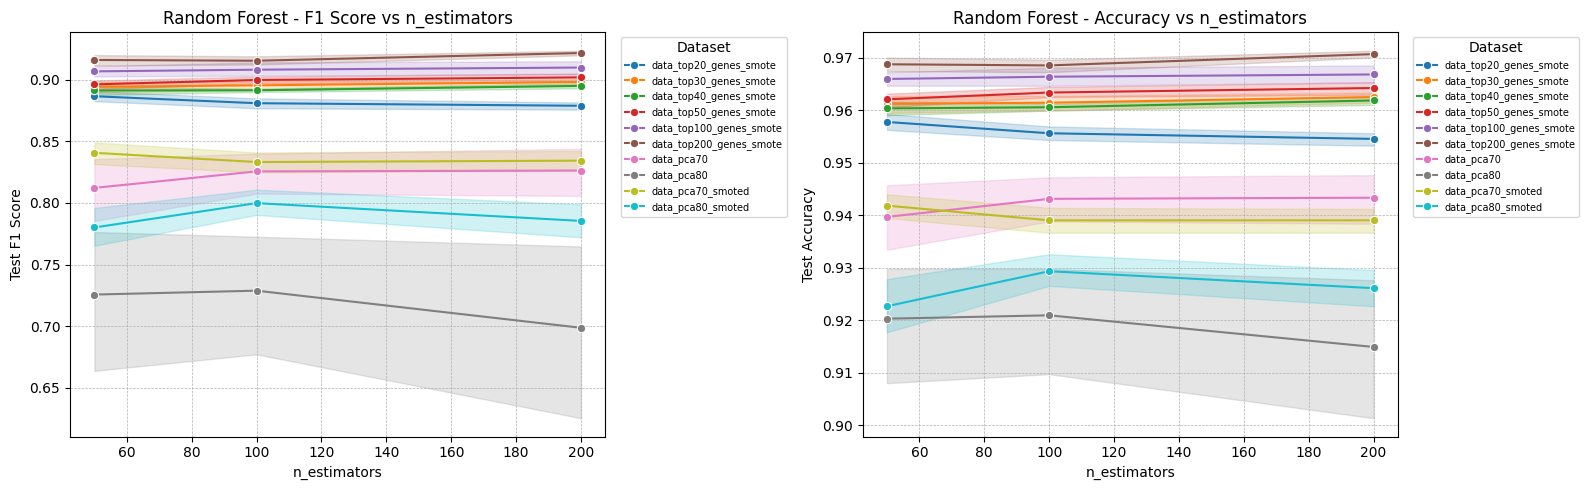

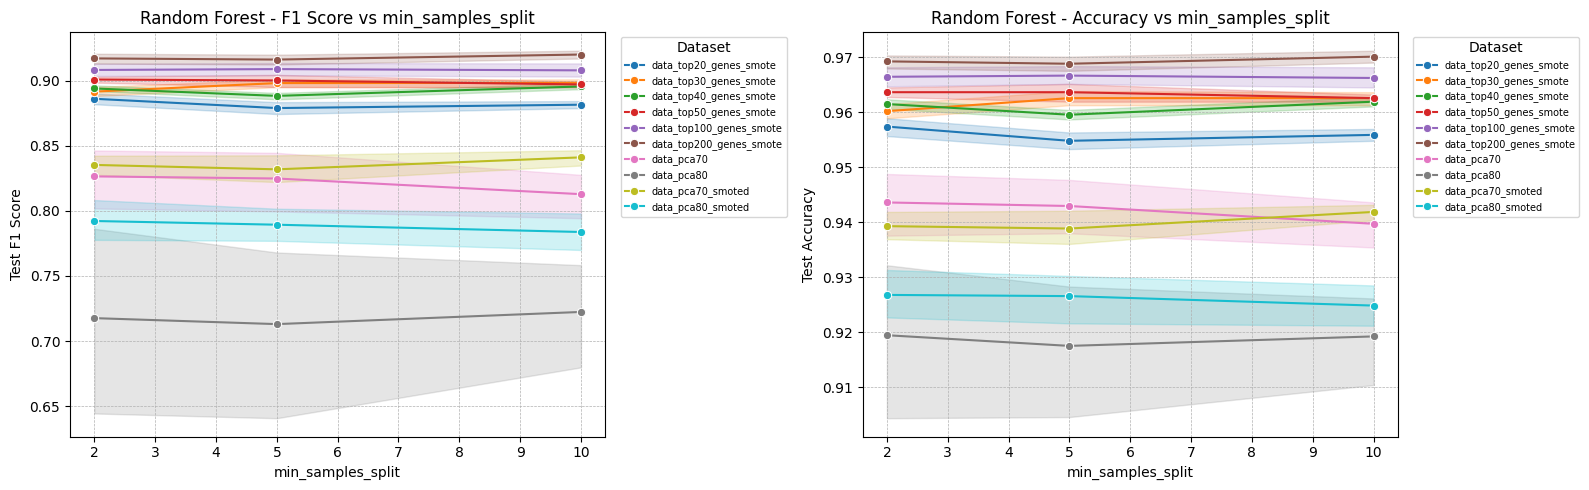

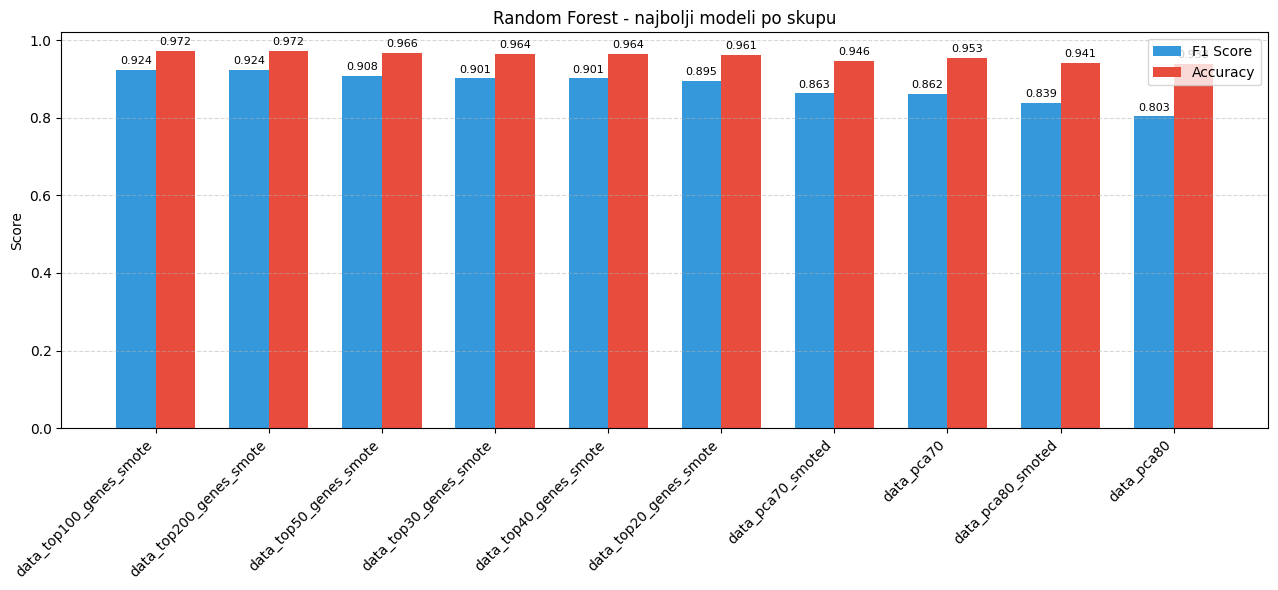


=== Random Forest - najbolji modeli po skupu ===
                   file  n_estimators  max_depth  min_samples_split  mean_cv_f1  mean_cv_accuracy  test_f1  test_accuracy
data_top100_genes_smote           100        5.0                  2    0.975474          0.975630 0.924138       0.971576
data_top200_genes_smote            50       15.0                 10    0.982738          0.983052 0.924138       0.971576
 data_top50_genes_smote           100       15.0                  5    0.983590          0.983582 0.907801       0.966408
 data_top30_genes_smote            50       10.0                  2    0.969805          0.970348 0.901408       0.963824
 data_top40_genes_smote            50       10.0                 10    0.977151          0.977236 0.901408       0.963824
 data_top20_genes_smote            50       10.0                  2    0.970919          0.971410 0.895105       0.961240
      data_pca70_smoted            50        5.0                 10    0.920202          0.93224

In [12]:
plot_param_curves(all_rf, x_param='n_estimators',      title_prefix='Random Forest')
plot_param_curves(all_rf, x_param='min_samples_split', title_prefix='Random Forest')

best_rf = plot_best_per_file(all_rf, title='Random Forest - najbolji modeli po skupu')

Najbolji RF model:
  Skup:        data_top100_genes_smote
  n_estimators=100, max_depth=5.0, min_split=2
  Test F1: 0.9241, Test Acc: 0.9716


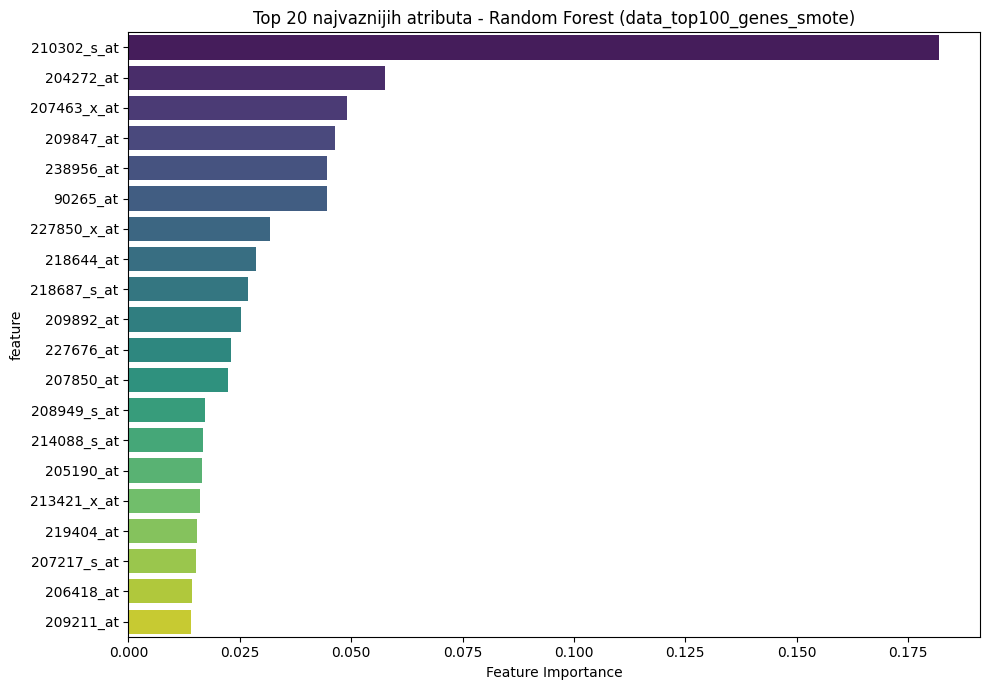

In [13]:
best_overall = all_rf.loc[all_rf['test_f1'].idxmax()]
print(f'Najbolji RF model:')
print(f'  Skup:        {best_overall["file"]}')
print(f'  n_estimators={best_overall["n_estimators"]}, max_depth={best_overall["max_depth"]}, min_split={best_overall["min_samples_split"]}')
print(f'  Test F1: {best_overall["test_f1"]:.4f}, Test Acc: {best_overall["test_accuracy"]:.4f}')

df_tr = pd.read_csv(f'data/{best_overall["file"]}_train.csv')
X_tr = df_tr.drop('target', axis=1)
y_tr = df_tr['target']

best_model = RandomForestClassifier(
    n_estimators=int(best_overall['n_estimators']),
    max_depth=None if pd.isna(best_overall['max_depth']) else int(best_overall['max_depth']),
    min_samples_split=int(best_overall['min_samples_split']),
    random_state=42, n_jobs=-1
)
best_model.fit(X_tr, y_tr)

fi = pd.DataFrame({
    'feature': X_tr.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=fi, y='feature', x='importance', ax=ax, palette='viridis')
ax.set_title(f'Top 20 najvaznijih atributa - Random Forest ({best_overall["file"]})')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()


## Algoritam 5 - Linear SVM

In [14]:
param_grid_svm = {
    'C':    [0.001, 0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge']
}

def svm_factory(**params):
    return LinearSVC(**params, max_iter=5000, dual='auto', random_state=42)

all_svm = run_classifier(svm_factory, SVM_data, param_grid_svm)
all_svm.to_csv('linear_svm_all_results.csv', index=False)
print(f'Sacuvano: linear_svm_all_results.csv ({len(all_svm)} kombinacija)')

Sacuvano: linear_svm_all_results.csv (120 kombinacija)


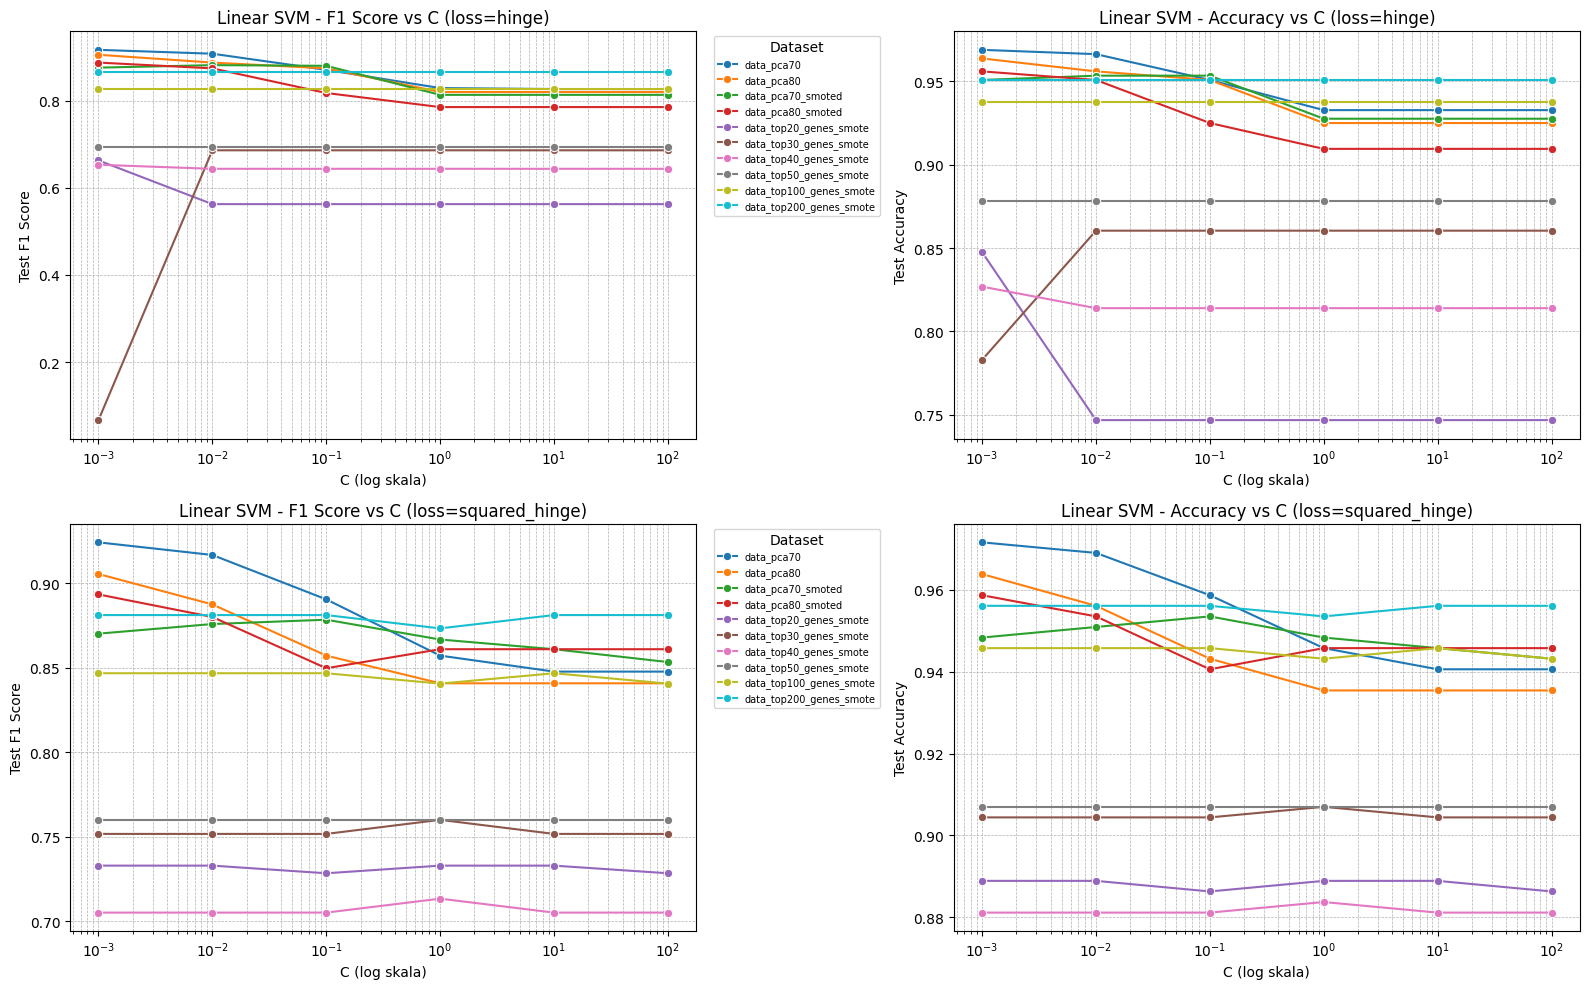

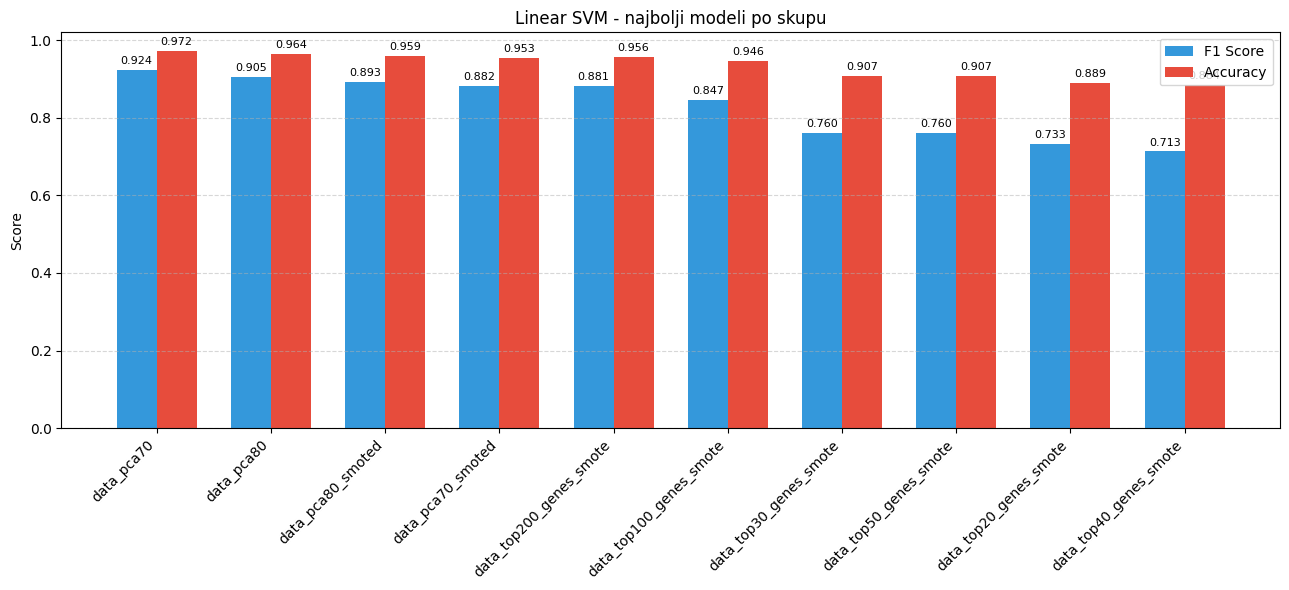


=== Linear SVM - najbolji modeli po skupu ===
                   file     C          loss  mean_cv_f1  mean_cv_accuracy  test_f1  test_accuracy
             data_pca70 0.001 squared_hinge    0.862542          0.945585 0.924138       0.971576
             data_pca80 0.001         hinge    0.866521          0.947313 0.905405       0.963824
      data_pca80_smoted 0.001 squared_hinge    0.946103          0.943326 0.893333       0.958656
      data_pca70_smoted 0.010         hinge    0.966983          0.966102 0.881579       0.953488
data_top200_genes_smote 0.001 squared_hinge    0.950123          0.952889 0.881119       0.956072
data_top100_genes_smote 0.001 squared_hinge    0.941729          0.945462 0.846715       0.945736
 data_top30_genes_smote 1.000 squared_hinge    0.910675          0.913143 0.760000       0.906977
 data_top50_genes_smote 0.001 squared_hinge    0.883292          0.891445 0.760000       0.906977
 data_top20_genes_smote 0.001 squared_hinge    0.893898          0.8956

In [15]:
plot_param_curves(all_svm, x_param='C', group_col='loss', log_x=True, title_prefix='Linear SVM')
best_svm = plot_best_per_file(all_svm, title='Linear SVM - najbolji modeli po skupu')

## Algoritam 6 - k najblizih suseda (k-NN)

In [16]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

def knn_factory(**params):
    return KNeighborsClassifier(**params, n_jobs=-1)

all_knn = run_classifier(knn_factory, KNN_data, param_grid_knn)
all_knn.to_csv('knn_all_results.csv', index=False)
print(f'Sacuvano: knn_all_results.csv ({len(all_knn)} kombinacija)')

Sacuvano: knn_all_results.csv (112 kombinacija)


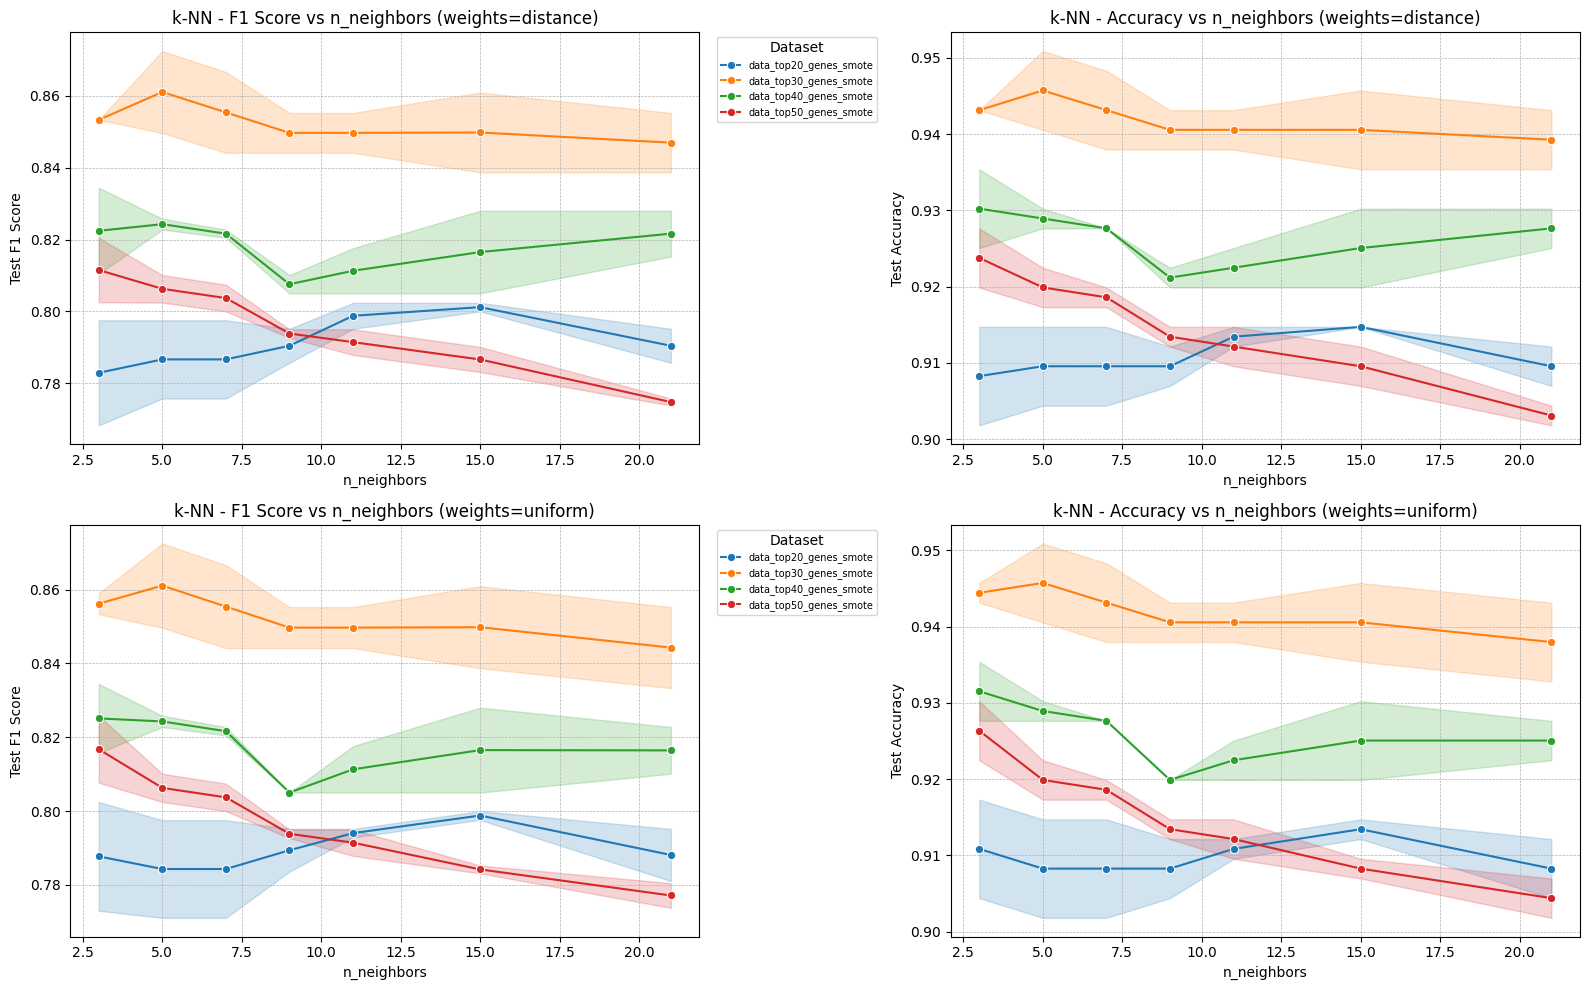

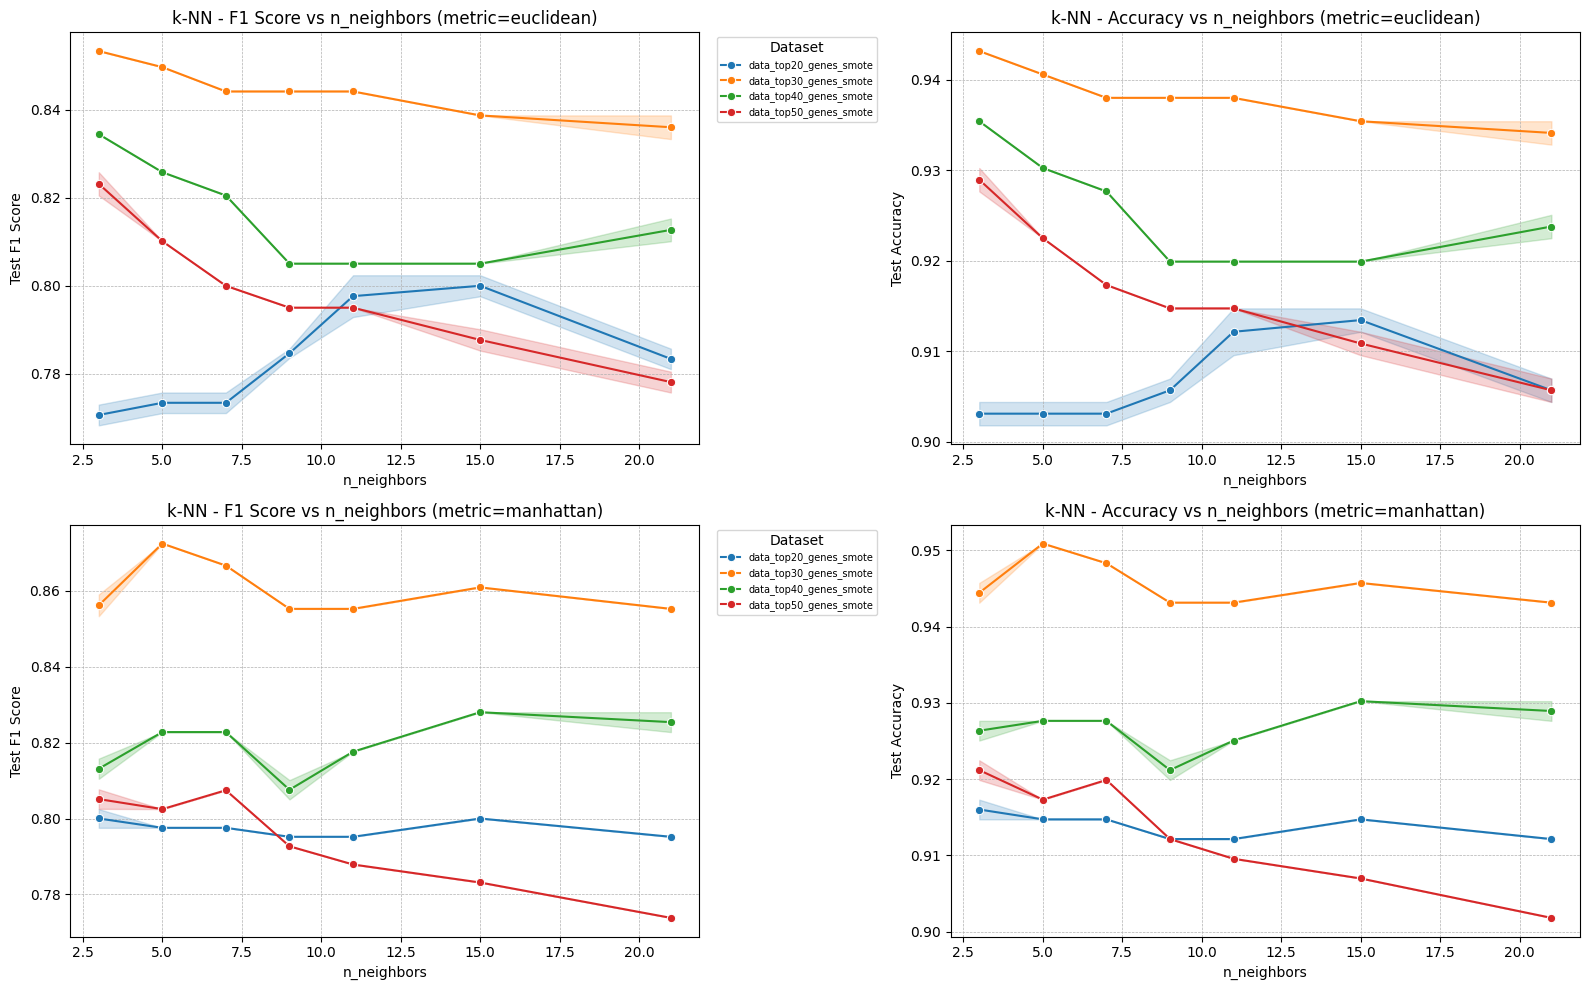

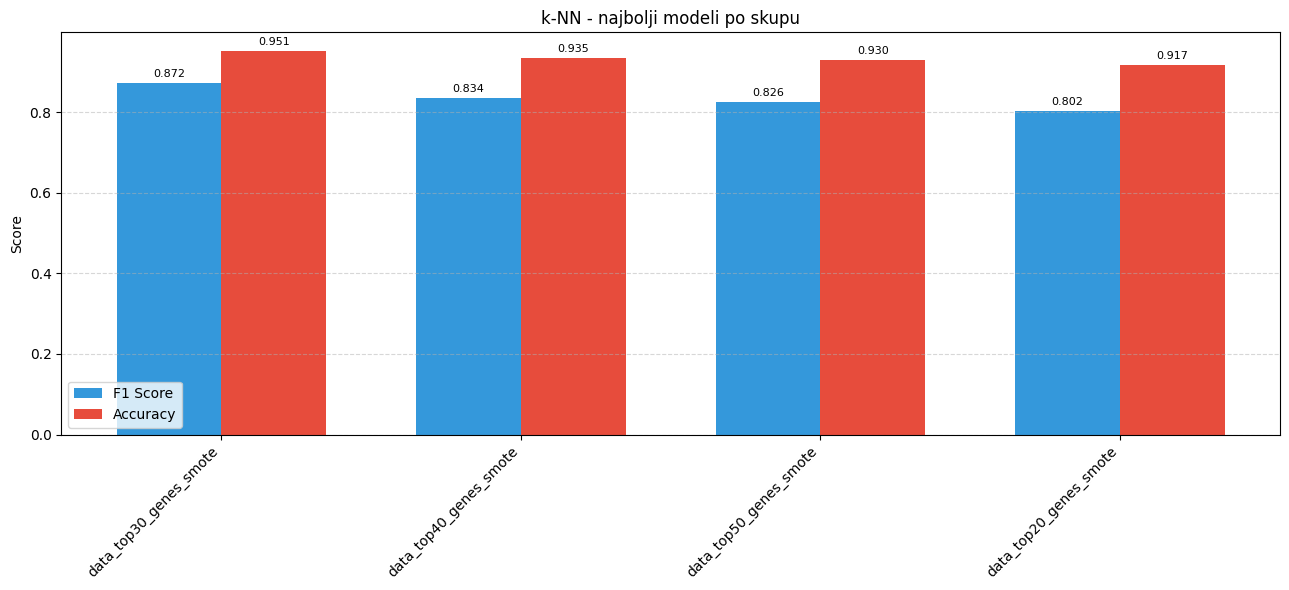


=== k-NN - najbolji modeli po skupu ===
                  file  n_neighbors weights    metric  mean_cv_f1  mean_cv_accuracy  test_f1  test_accuracy
data_top30_genes_smote            5 uniform manhattan    0.959322          0.959763 0.872483       0.950904
data_top40_genes_smote            3 uniform euclidean    0.934305          0.936473 0.834437       0.935401
data_top50_genes_smote            3 uniform euclidean    0.936477          0.937003 0.825806       0.930233
data_top20_genes_smote            3 uniform manhattan    0.937105          0.936996 0.802469       0.917313

F1 vs Accuracy (gap -> nebalansiranost):
                  file  test_f1  test_accuracy    gap
data_top30_genes_smote 0.872483       0.950904 0.0784
data_top40_genes_smote 0.834437       0.935401 0.1010
data_top50_genes_smote 0.825806       0.930233 0.1044
data_top20_genes_smote 0.802469       0.917313 0.1148


In [17]:
plot_param_curves(all_knn, x_param='n_neighbors', group_col='weights', title_prefix='k-NN')
plot_param_curves(all_knn, x_param='n_neighbors', group_col='metric',  title_prefix='k-NN')
best_knn = plot_best_per_file(all_knn, title='k-NN - najbolji modeli po skupu')

## Pregled - najbolji rezultat svakog algoritma

In [18]:
def best_overall(df, name):
    row = df.loc[df['test_f1'].idxmax()].to_dict()
    return {
        'algoritam':     name,
        'fajl':          row['file'],
        'test_f1':       round(row['test_f1'], 4),
        'test_accuracy': round(row['test_accuracy'], 4),
        'mean_cv_f1':    round(row['mean_cv_f1'], 4)
    }

summary_rows = [
    best_overall(all_lr,  'Logisticka regresija'),
    best_overall(all_nb,  'Naive Bayes'),
    best_overall(all_xgb, 'XGBoost'),
    best_overall(all_rf,  'Random Forest'),
    best_overall(all_svm, 'Linear SVM'),
    best_overall(all_knn, 'k-NN')
]
summary_df = pd.DataFrame(summary_rows).sort_values('test_f1', ascending=False).reset_index(drop=True)
summary_df.index += 1
print('=== NAJBOLJI MODEL PO ALGORITMU (sortirano po F1) ===')
print(summary_df.to_string())

=== NAJBOLJI MODEL PO ALGORITMU (sortirano po F1) ===
              algoritam                     fajl  test_f1  test_accuracy  mean_cv_f1
1  Logisticka regresija               data_pca80   0.9306         0.9742      0.8923
2         Random Forest  data_top100_genes_smote   0.9241         0.9716      0.9755
3            Linear SVM               data_pca70   0.9241         0.9716      0.8625
4               XGBoost        data_pca70_smoted   0.9231         0.9716      0.9677
5           Naive Bayes                 data_raw   0.9078         0.9664      0.9042
6                  k-NN   data_top30_genes_smote   0.8725         0.9509      0.9593
